In [11]:
# ICVul
import pandas as pd

# 1. Load the datasets
df_labels = pd.read_csv('../data/intermediate/zcommits_icvul.csv')
df_metrics = pd.read_csv('../data/raw/commit_info.csv')

# 2. Merge the dataframes
df_vuln = pd.merge(
    df_labels, 
    df_metrics, 
    left_on='commit_id', 
    right_on='hash', 
    how='inner'
)

# 3. Define Metrics
# 'Changed' is the sum of added and deleted
df_vuln['lines_added'] = df_vuln['num_lines_added']
df_vuln['lines_removed'] = df_vuln['num_lines_deleted']
df_vuln['lines_changed'] = df_vuln['num_lines_added'] + df_vuln['num_lines_deleted']
df_vuln['lines_changed_og'] = df_vuln['num_lines_changed']

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

# 4. Group by commit_role and calculate statistics for ALL three metrics
# This creates a MultiIndex column structure which is very helpful for comparison
metrics = ['lines_added', 'lines_removed', 'lines_changed', 'lines_changed_og']
stats = df_vuln.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Vulnerability Statistics (ICVul):")
print(stats.round(2))

Vulnerability Statistics (ICVul):
            lines_added                lines_removed                \
                 median     mean count        median    mean count   
commit_role                                                          
VFC                 8.0    88.09  3911           2.0   15.48  3911   
VIC               108.0  5166.27  8255          25.0  902.19  8255   

            lines_changed                lines_changed_og                 
                   median     mean count           median     mean count  
commit_role                                                               
VFC                  11.0   103.57  3911             11.0   103.57  3911  
VIC                 164.0  6068.46  8255            164.0  6068.46  8255  


In [12]:
# KFC (Linux)
import pandas as pd

# 1. Load the datasets
df_churn = pd.read_csv('../data/intermediate/churn.csv')
df_labels = pd.read_csv('../data/intermediate/commits_dataset_linux.csv')

# 2. Merge the datasets on 'commit_id'
df_bug = pd.merge(df_labels, df_churn, on='commit_id', how='inner')

# 3. Define Metrics (Aligning with the Vulnerability dataset)
df_bug['lines_added'] = df_bug['num_lines_added']
df_bug['lines_removed'] = df_bug['num_lines_deleted']
df_bug['lines_changed'] = df_bug['num_lines_added'] + df_bug['num_lines_deleted']

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

# 4. Group by commit_role and calculate stats for all three metrics
metrics = ['lines_added', 'lines_removed', 'lines_changed']
stats = df_bug.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Bug Statistics (Linux KFC):")
print(stats.round(2))

# 5. Optional: Average Files Changed
files_stats = df_bug.groupby('commit_role')['files_changed'].mean()
print("\nAverage Files Changed:")
print(files_stats)

Bug Statistics (Linux KFC):
            lines_added                 lines_removed               \
                 median      mean count        median   mean count   
commit_role                                                          
BFC                 3.0      8.04   510           1.0   4.28   510   
BIC                79.0  14121.78   490           5.0  25.42   490   

            lines_changed                  
                   median      mean count  
commit_role                                
BFC                   5.0     12.32   510  
BIC                 110.5  14147.20   490  

Average Files Changed:
commit_role
BFC     1.305882
BIC    39.355102
Name: files_changed, dtype: float64


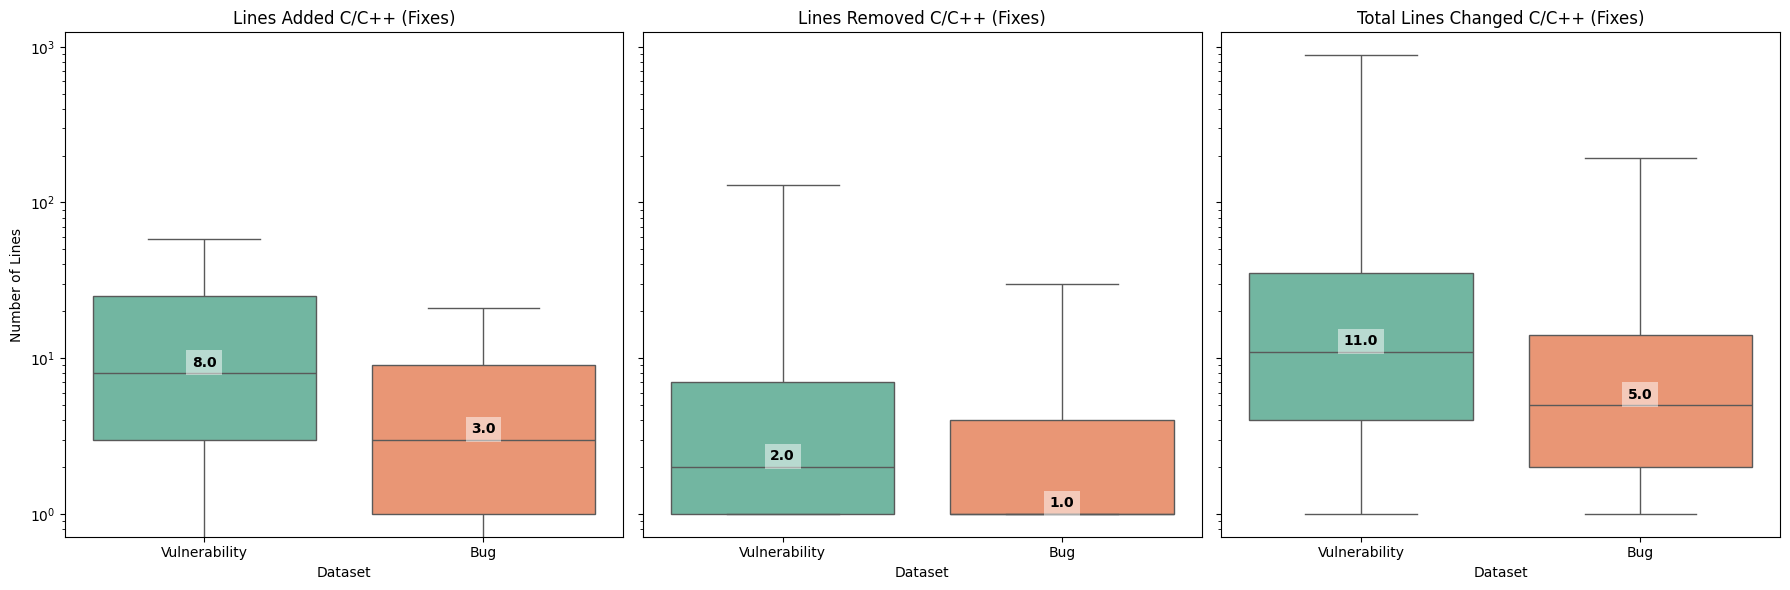

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_fixing = pd.concat([
    df_vuln[df_vuln['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_changed', 'Dataset']],
    df_bug[df_bug['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_changed', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_changed']
titles = ['Lines Added C/C++ (Fixes)', 'Lines Removed C/C++ (Fixes)', 'Total Lines Changed C/C++ (Fixes)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_fixing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    # We calculate medians grouped by Dataset for the specific metric
    medians = df_fixing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'{m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

In [14]:
# TOSEM
import pandas as pd

# 1. Load the manual vulnerability dataset
df_vuln_java = pd.read_csv('../data/intermediate/java_vuln_manual.csv')

# 2. Group by Type (VFC/VIC) and calculate stats
metrics = ['lines_added', 'lines_removed', 'lines_changed']
vuln_stats = df_vuln_java.groupby('Type')[metrics].agg(['median', 'mean', 'count'])

print("Java Vulnerability Statistics (Manual TOSEM):")
print(vuln_stats.round(2))

# 3. Preparation for Plotting
# We make a copy specifically for the "Fixes" comparison plot
# and ensure the 'Group' label matches the style of your other sets
df_java_vfc_only = df_vuln_java[df_vuln_java['Type'] == 'VFC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

Java Vulnerability Statistics (Manual TOSEM):
     lines_added                 lines_removed               lines_changed  \
          median      mean count        median    mean count        median   
Type                                                                         
VFC         49.0    217.92   186           9.0   57.01   186          61.0   
VIC        404.5  30165.29    94          28.5  754.79    94         505.0   

                      
          mean count  
Type                  
VFC     274.93   186  
VIC   30920.07    94  


In [15]:
# DS_APACHE
import pandas as pd

# 1. Load the datasets
df_churn_java = pd.read_csv('../data/intermediate/churn_ds_apache.csv')
df_labels = pd.read_csv('../data/intermediate/commits_ds_apache.csv')

# 2. Merge the datasets on 'commit_id'
df_bug_java = pd.merge(df_labels, df_churn_java, on='commit_id', how='inner')

# 3. Define Metrics (Aligning with the Vulnerability dataset)
df_bug_java['lines_added'] = df_bug_java['num_lines_added']
df_bug_java['lines_removed'] = df_bug_java['num_lines_deleted']
df_bug_java['lines_changed'] = df_bug_java['num_lines_added'] + df_bug_java['num_lines_deleted']

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

# 4. Group by commit_role and calculate stats for all three metrics
metrics = ['lines_added', 'lines_removed', 'lines_changed']
stats = df_bug_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Bug Statistics (DS_APACHE):")
print(stats.round(2))

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()

# 5. Optional: Average Files Changed
files_stats = df_bug_java.groupby('commit_role')['files_changed'].mean()
print("\nAverage Files Changed:")
print(files_stats)

Bug Statistics (DS_APACHE):
            lines_added               lines_removed                \
                 median    mean count        median    mean count   
commit_role                                                         
BFC                20.0   59.03   235           6.0   24.93   235   
BIC               101.0  444.84   315          22.0  175.51   315   

            lines_changed                
                   median    mean count  
commit_role                              
BFC                  32.0   83.96   235  
BIC                 131.0  620.35   315  

Average Files Changed:
commit_role
BFC     2.659574
BIC    12.793651
Name: files_changed, dtype: float64


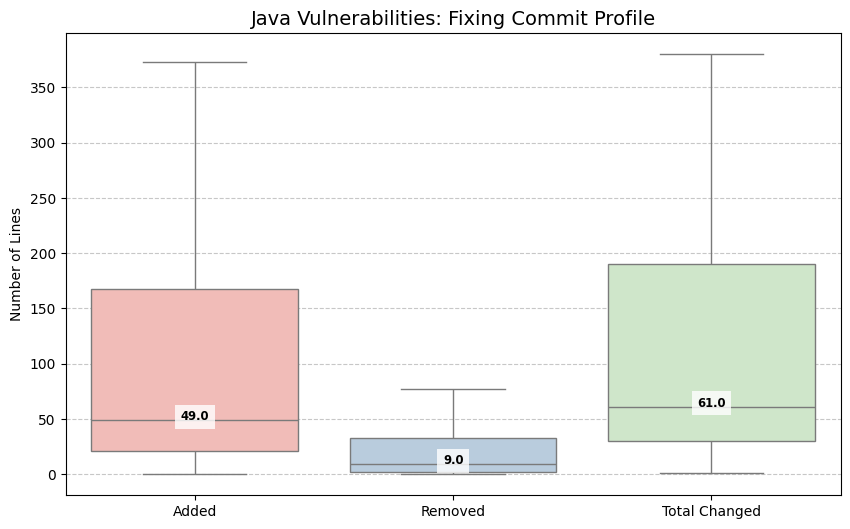

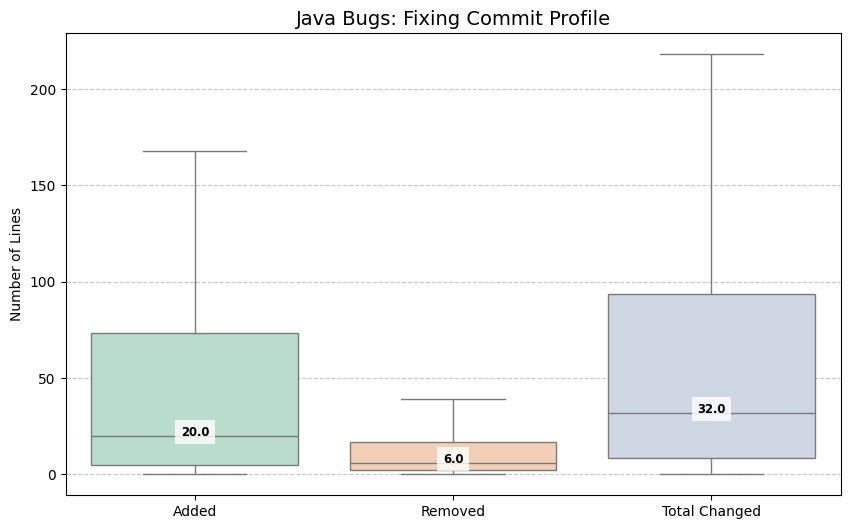

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Function to plot the "Internal Profile" to avoid repeating code
def plot_internal_profile(df, title, palette_name):
    # Melt the dataframe for boxplot compatibility
    df_melt = df.melt(value_vars=['lines_added', 'lines_removed', 'lines_changed'], 
                      var_name='Metric', value_name='Lines')
    
    plt.figure(figsize=(10, 6))
    
    # Create the boxplot
    ax = sns.boxplot(data=df_melt, x='Metric', y='Lines', hue='Metric',
                     showfliers=False, palette=palette_name, legend=False)
    
    # Add Median text labels on top of each box
    medians = df_melt.groupby(['Metric'])['Lines'].median()
    
    # Explicitly map the x-ticks to the metric names used in the melt
    metric_order = ['lines_added', 'lines_removed', 'lines_changed']
    
    for xtick in ax.get_xticks():
        metric_name = metric_order[xtick]
        median_val = medians[metric_name]
        
        # Place text slightly above the median line
        ax.text(xtick, median_val, f'{median_val:.1f}', 
                horizontalalignment='center', size='small', color='black', 
                weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    plt.title(title, fontsize=14)
    plt.xticks([0, 1, 2], ['Added', 'Removed', 'Total Changed'])
    plt.xlabel('')
    plt.ylabel('Number of Lines')
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.show()

plot_internal_profile(df_java_vfc_only, "Java Vulnerabilities: Fixing Commit Profile", "Pastel1")

plot_internal_profile(df_java_bfc_only, "Java Bugs: Fixing Commit Profile", "Pastel2")

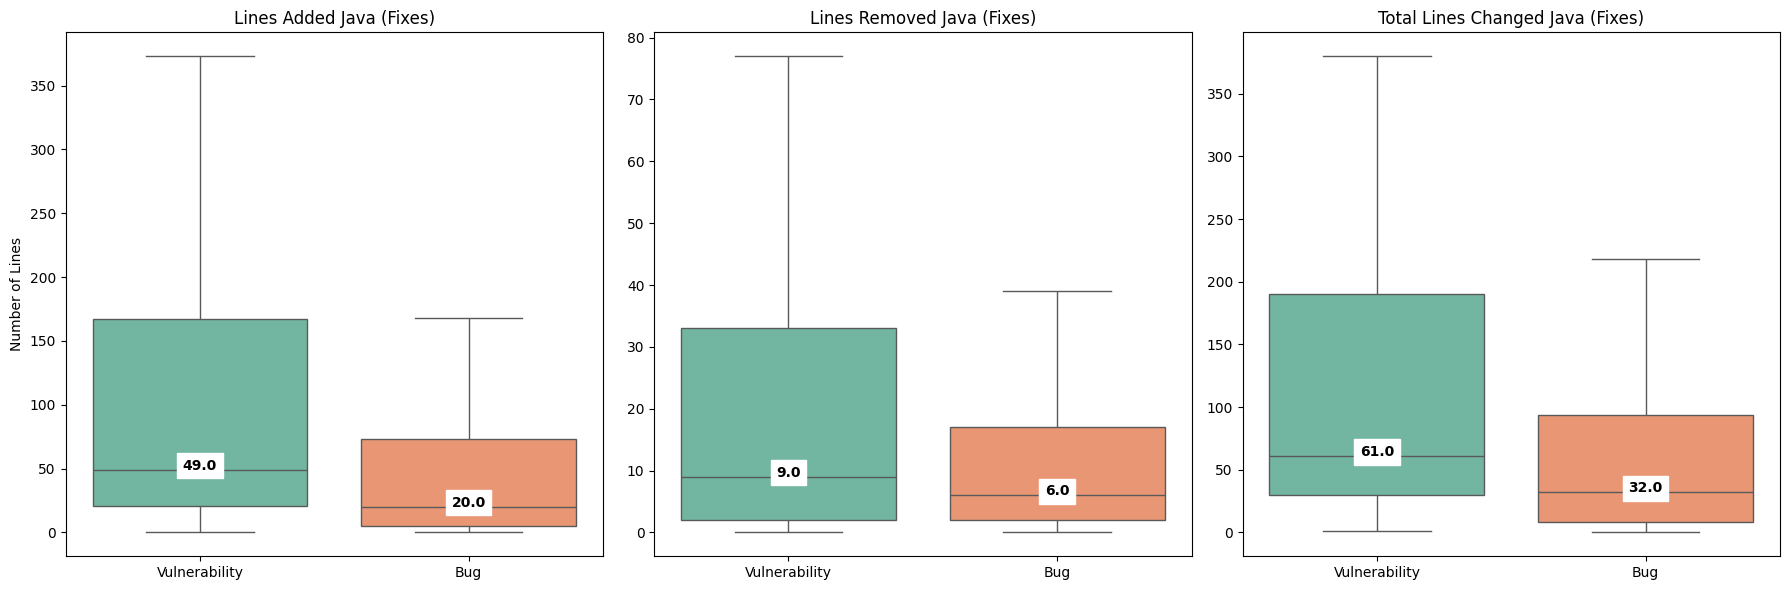

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_changed']
titles = ['Lines Added Java (Fixes)', 'Lines Removed Java (Fixes)', 'Total Lines Changed Java (Fixes)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'{m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()